In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.style.use('dark_background')
sns.set_palette("rocket")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.facecolor'] = '#161a22'
plt.rcParams['figure.facecolor'] = '#0d0f12'

df = pd.read_excel("../Data/base_recomendacao_avancada.xlsx")
print(f"✅ Base carregada: {df.shape[0]} filmes × {df.shape[1]} colunas")
df.head()


✅ Base carregada: 1500 filmes × 14 colunas


,id,title,Ano,Generos,vote_count,vote_average,É_Cultural,Certeza_IA_(%),Justificativa_Validacao,Temas_Recomendacao,Atmosfera_Filme,Titulo_PT,Temas_PT,Atmosfera_PT
0,27205,Inception,2010,"Action, Thriller, Science Fiction, Mystery, Ad...",14075,8.1,0,19.9,Foco Comercial: Classificado primariamente com...,revenge and justice | coming of age,mind-bending and complex,Começo,vingança e justiça | maioridade,alucinante e complexo
1,155,The Dark Knight,2008,"Drama, Action, Crime, Thriller",12269,8.3,1,27.2,Relevância Cultural: O roteiro foca fortemente...,war and conflict | coming of age,tense and suspenseful,O Cavaleiro das Trevas,guerra e conflito | maioridade,tenso e cheio de suspense
2,19995,Avatar,2009,"Action, Adventure, Fantasy, Science Fiction",12114,7.2,1,29.5,Relevância Cultural: O roteiro foca fortemente...,space exploration | war and conflict,mind-bending and complex,avatar,exploração espacial | guerra e conflito,alucinante e complexo
3,24428,The Avengers,2012,"Science Fiction, Action, Adventure",12000,7.4,0,25.1,Foco Comercial: Classificado primariamente com...,superheroes | war and conflict,mind-bending and complex,Os Vingadores,super-heróis | guerra e conflito,alucinante e complexo
4,293660,Deadpool,2016,"Action, Adventure, Comedy",11444,7.4,1,26.7,Relevância Cultural: O roteiro foca fortemente...,coming of age | revenge and justice,fun and energetic,Piscina morta,maioridade | vingança e justiça,divertido e enérgico


In [6]:
COLUNAS_USADAS = [
    'id', 'title', 'Titulo_PT', 'Ano', 'Generos',
    'vote_count', 'vote_average', 'É_Cultural',
    'Certeza_IA_(%)', 'Justificativa_Validacao',
    'Temas_PT', 'Atmosfera_PT'
]

print("📋 COLUNAS UTILIZADAS NO SISTEMA DE RECOMENDAÇÃO\n")
tabela_colunas = pd.DataFrame({
    'Coluna': COLUNAS_USADAS,
    'Tipo': [df[c].dtype for c in COLUNAS_USADAS],
    'Valores Únicos': [df[c].nunique() for c in COLUNAS_USADAS],
    'Nulos': [df[c].isna().sum() for c in COLUNAS_USADAS]
})
tabela_colunas


📋 COLUNAS UTILIZADAS NO SISTEMA DE RECOMENDAÇÃO



,Coluna,Tipo,Valores Únicos,Nulos
0,id,int64,1500,0
1,title,str,1479,0
2,Titulo_PT,str,1474,0
3,Ano,int64,73,0
4,Generos,str,592,0
5,vote_count,int64,1110,0
6,vote_average,float64,43,0
7,É_Cultural,int64,2,0
8,Certeza_IA_(%),float64,555,0
9,Justificativa_Validacao,str,8,0


In [7]:
print("📊 ESTATÍSTICAS GERAIS DO DATASET\n")
resumo = pd.DataFrame({
    'Métrica': [
        'Total de filmes',
        'Período (anos)',
        'Nota média geral',
        'Nota mediana',
        'Filmes culturais',
        'Filmes comerciais',
        'Confiança média da IA (%)',
        'Gêneros únicos identificados'
    ],
    'Valor': [
        len(df),
        f"{int(df['Ano'].min())} - {int(df['Ano'].max())}",
        round(df['vote_average'].mean(), 2),
        round(df['vote_average'].median(), 2),
        int((df['É_Cultural'] == 1).sum()),
        int((df['É_Cultural'] == 0).sum()),
        round(df['Certeza_IA_(%)'].mean(), 1),
        len(set(g.strip() for gs in df['Generos'].dropna() for g in gs.split(',')))
    ]
})
resumo


📊 ESTATÍSTICAS GERAIS DO DATASET



,Métrica,Valor
0,Total de filmes,1500
1,Período (anos),1936 - 2017
2,Nota média geral,6.72
3,Nota mediana,6.7
4,Filmes culturais,1155
5,Filmes comerciais,345
6,Confiança média da IA (%),39.8
7,Gêneros únicos identificados,18


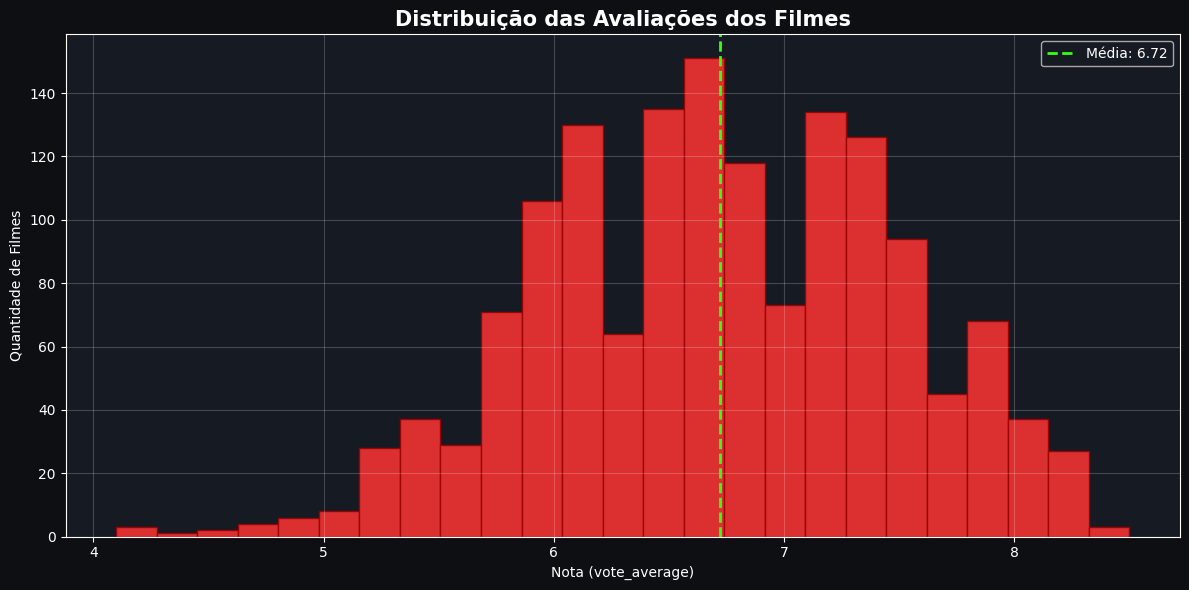

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['vote_average'], bins=25, color='#ff3333', edgecolor='#990000', alpha=0.85)
ax.axvline(df['vote_average'].mean(), color='#39ff14', linestyle='--',
           linewidth=2, label=f"Média: {df['vote_average'].mean():.2f}")
ax.set_title('Distribuição das Avaliações dos Filmes', fontsize=15, fontweight='bold')
ax.set_xlabel('Nota (vote_average)')
ax.set_ylabel('Quantidade de Filmes')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../Imagens/grafico_01_distribuicao_notas.png', dpi=120, facecolor='#0d0f12')
plt.show()


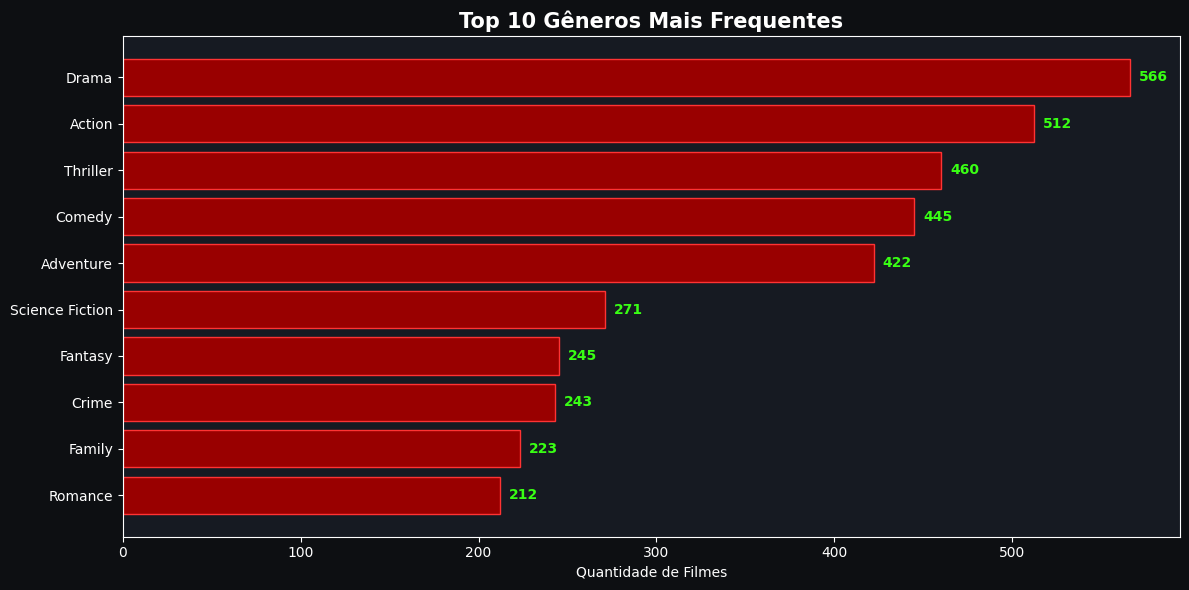

In [10]:
todos_generos = []
for gs in df['Generos'].dropna():
    todos_generos.extend([g.strip() for g in gs.split(',')])

contagem = Counter(todos_generos).most_common(10)
generos, freqs = zip(*contagem)

fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.barh(generos[::-1], freqs[::-1], color='#990000', edgecolor='#ff3333')
ax.set_title('Top 10 Gêneros Mais Frequentes', fontsize=15, fontweight='bold')
ax.set_xlabel('Quantidade de Filmes')
for i, v in enumerate(freqs[::-1]):
    ax.text(v + 5, i, str(v), color='#39ff14', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../Imagens/grafico_02_top_generos.png', dpi=120, facecolor='#0d0f12')
plt.show()


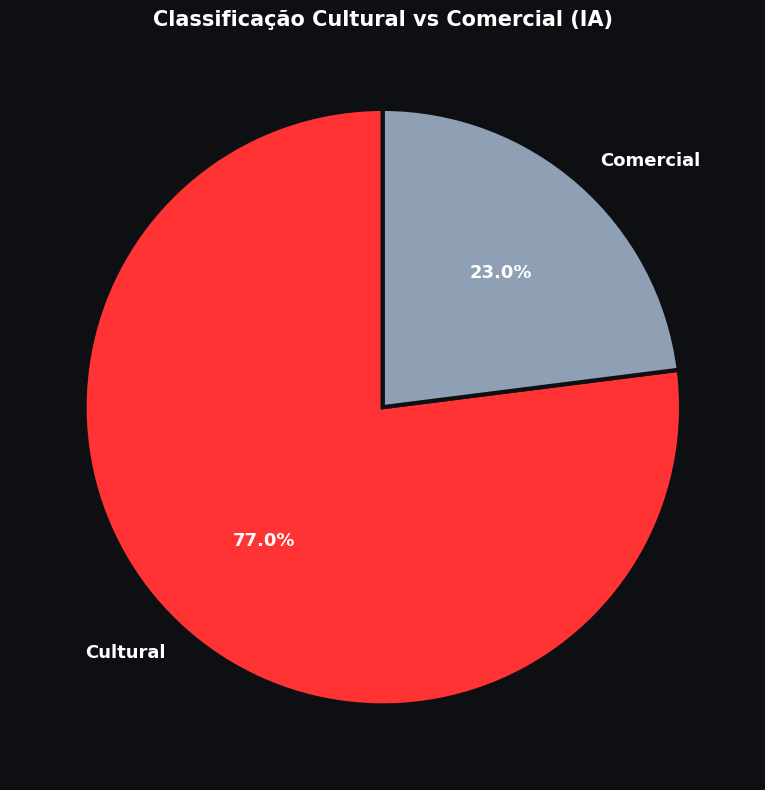

In [11]:
contagem_cult = df['É_Cultural'].value_counts()
labels = ['Cultural', 'Comercial']
cores = ['#ff3333', '#8fa0b5']

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(contagem_cult.values, labels=labels, colors=cores, autopct='%1.1f%%',
       startangle=90, textprops={'color': 'white', 'fontsize': 13, 'fontweight': 'bold'},
       wedgeprops={'edgecolor': '#0d0f12', 'linewidth': 3})
ax.set_title('Classificação Cultural vs Comercial (IA)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../Imagens/grafico_03_cultural_vs_comercial.png', dpi=120, facecolor='#0d0f12')
plt.show()


C:\Users\Xno\AppData\Local\Temp\ipykernel_29248\189380451.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dados_cult, dados_com], labels=['Cultural', 'Comercial'],


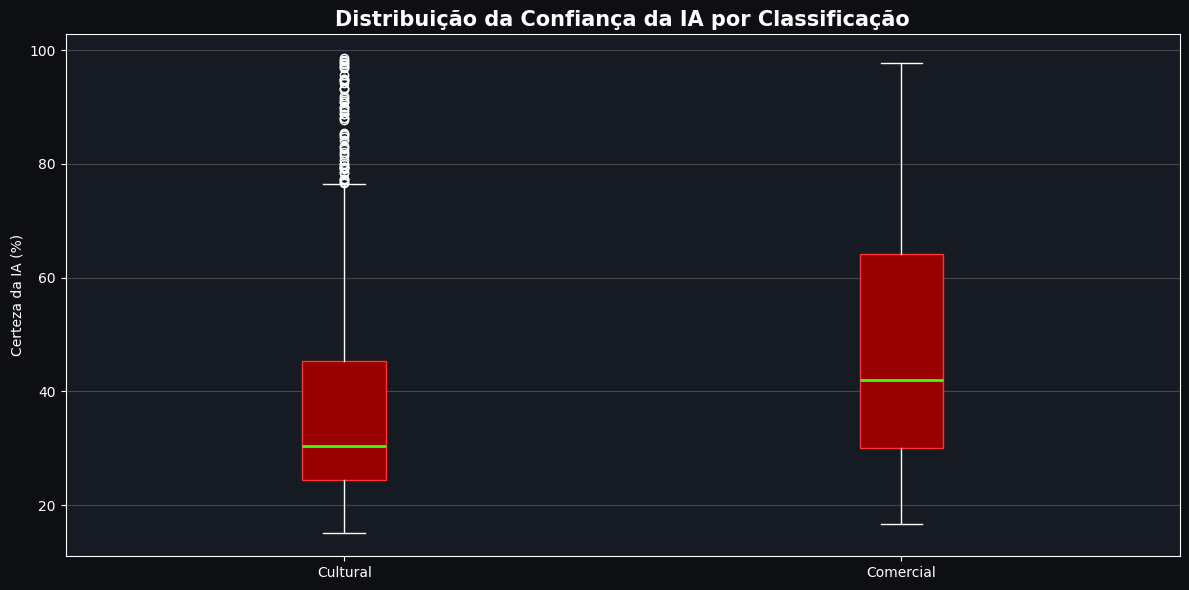

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
dados_cult = df[df['É_Cultural'] == 1]['Certeza_IA_(%)']
dados_com  = df[df['É_Cultural'] == 0]['Certeza_IA_(%)']

ax.boxplot([dados_cult, dados_com], labels=['Cultural', 'Comercial'],
           patch_artist=True,
           boxprops=dict(facecolor='#990000', color='#ff3333'),
           medianprops=dict(color='#39ff14', linewidth=2),
           whiskerprops=dict(color='white'),
           capprops=dict(color='white'))
ax.set_title('Distribuição da Confiança da IA por Classificação', fontsize=15, fontweight='bold')
ax.set_ylabel('Certeza da IA (%)')
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('../Imagens/grafico_04_confianca_ia.png', dpi=120, facecolor='#0d0f12')
plt.show()


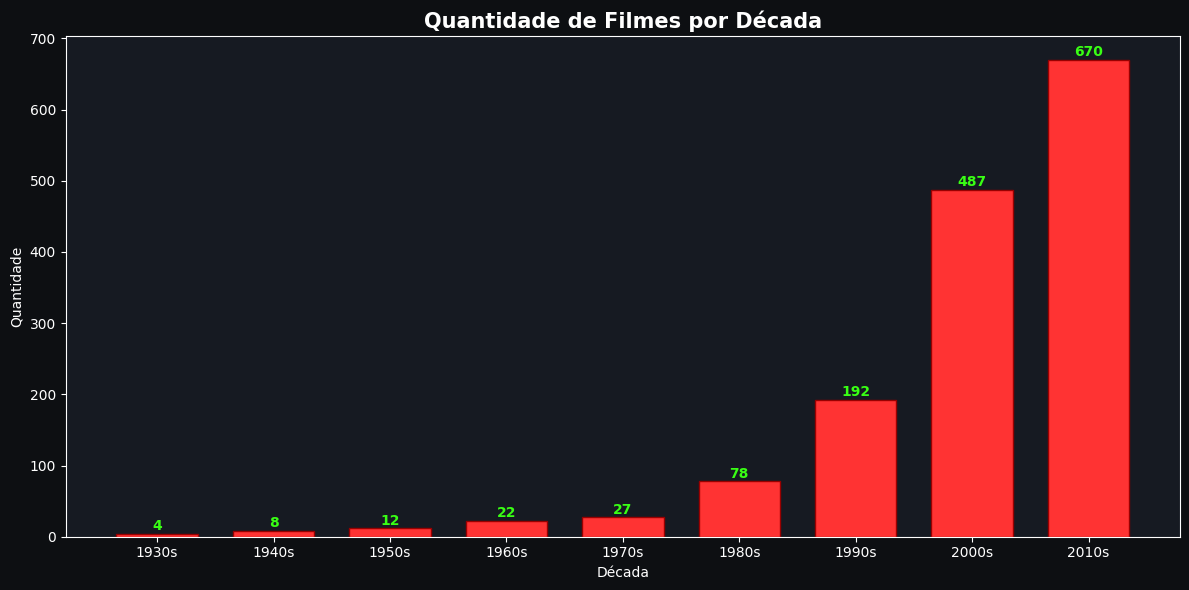

In [13]:
df['Decada'] = (df['Ano'] // 10) * 10
por_decada = df['Decada'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(por_decada.index.astype(str) + 's', por_decada.values,
       color='#ff3333', edgecolor='#990000', width=0.7)
ax.set_title('Quantidade de Filmes por Década', fontsize=15, fontweight='bold')
ax.set_xlabel('Década')
ax.set_ylabel('Quantidade')
for i, v in enumerate(por_decada.values):
    ax.text(i, v + 5, str(v), ha='center', color='#39ff14', fontweight='bold')
plt.tight_layout()
plt.savefig('../Imagens/grafico_05_filmes_por_decada.png', dpi=120, facecolor='#0d0f12')
plt.show()


In [ ]:
print("🏆 TOP 15 FILMES COM MAIORES NOTAS\n")
top15 = (df.sort_values(['vote_average', 'vote_count'], ascending=[False, False])
           .head(15)
           [['Titulo_PT', 'Ano', 'vote_average', 'vote_count', 'É_Cultural']]
           .reset_index(drop=True))
top15.columns = ['Título', 'Ano', 'Nota', 'Votos', 'Cultural']
top15


🏆 TOP 15 FILMES COM MAIORES NOTAS



,Título,Ano,Nota,Votos,Cultural
0,A Redenção de Shawshank,1994,8.5,8358,1
1,O padrinho,1972,8.5,6024,1
2,Seu nome.,2016,8.5,1030,0
3,O Cavaleiro das Trevas,2008,8.3,12269,1
4,Clube da Luta,1999,8.3,9678,1
5,Pulp Fiction,1994,8.3,8670,1
6,Lista de Schindler,1993,8.3,4436,1
7,Chicote,2014,8.3,4376,1
8,Afastado de espírito,2001,8.3,3968,1
9,A vida é bela,1997,8.3,3643,1


In [ ]:
print("🤖 EXEMPLOS DE CLASSIFICAÇÕES DA IA (amostra de 10)\n")
amostra = (df.sample(10, random_state=42)
             [['Titulo_PT', 'Generos', 'Temas_PT', 'Atmosfera_PT',
               'É_Cultural', 'Certeza_IA_(%)']]
             .reset_index(drop=True))
amostra


🤖 EXEMPLOS DE CLASSIFICAÇÕES DA IA (amostra de 10)



,Titulo_PT,Generos,Temas_PT,Atmosfera_PT,É_Cultural,Certeza_IA_(%)
0,Um dia,"Drama, Romance",amor e romance | maioridade,melancólico e dramático,0,91.0
1,Zoolander 2,Comedy,maioridade | vingança e justiça,divertido e enérgico,0,28.0
2,A Entrevista,"Action, Comedy",maioridade | vingança e justiça,divertido e enérgico,0,34.1
3,O Cavaleiro Solitário,"Action, Adventure, Western",vingança e justiça | guerra e conflito,tenso e cheio de suspense,1,68.9
4,Caça-fantasmas,"Action, Fantasy, Comedy",horror e paranormal | maioridade,divertido e enérgico,0,23.1
5,Querido João,"Drama, Romance, War",amor e romance | guerra e conflito,melancólico e dramático,0,42.1
6,A família,"Crime, Comedy, Action",dinâmica familiar | crime organizado,alucinante e complexo,1,45.4
7,Atirador,"Action, Drama, Mystery, Thriller, Crime",vingança e justiça | maioridade,tenso e cheio de suspense,1,21.3
8,Chifres,"Thriller, Horror, Drama, Fantasy",horror e paranormal | maioridade,tenso e cheio de suspense,1,26.9
9,Branca de Neve e o Caçador,"Adventure, Fantasy, Drama",dinâmica familiar | maioridade,melancólico e dramático,1,25.5


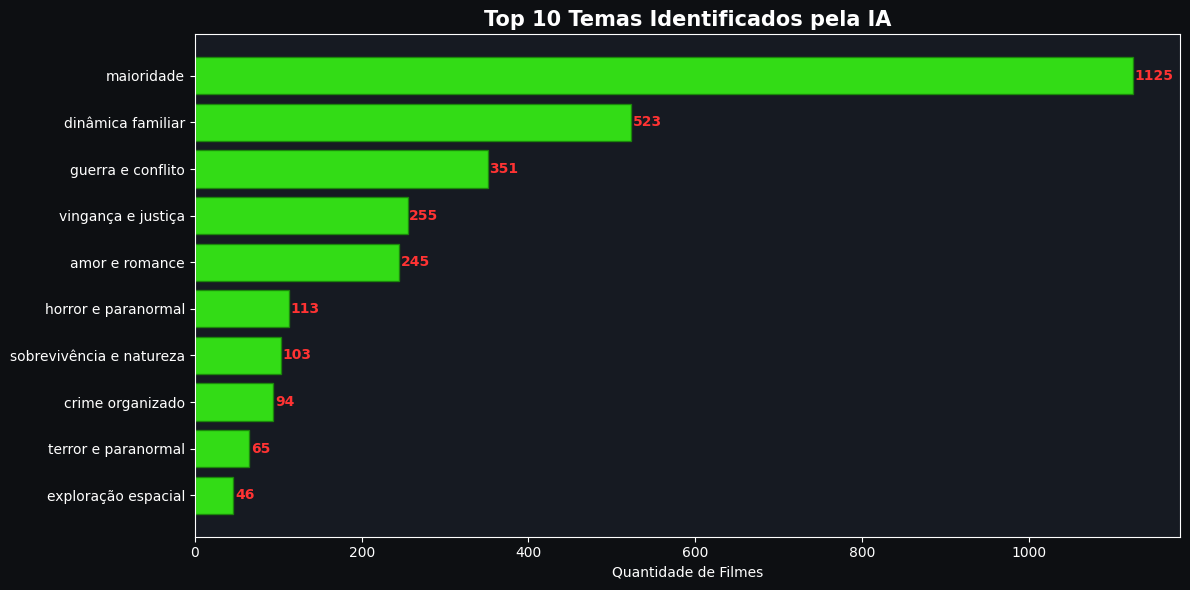

In [14]:
todos_temas = []
for ts in df['Temas_PT'].dropna():
    todos_temas.extend([t.strip() for t in ts.split('|')])

top_temas = Counter(todos_temas).most_common(10)
temas, freqs_t = zip(*top_temas)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(temas[::-1], freqs_t[::-1], color='#39ff14', edgecolor='#1a8a08', alpha=0.85)
ax.set_title('Top 10 Temas Identificados pela IA', fontsize=15, fontweight='bold')
ax.set_xlabel('Quantidade de Filmes')
for i, v in enumerate(freqs_t[::-1]):
    ax.text(v + 2, i, str(v), color='#ff3333', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../Imagens/grafico_06_top_temas.png', dpi=120, facecolor='#0d0f12')
plt.show()


In [ ]:
df_final = df[COLUNAS_USADAS].copy()
df_final.to_excel("base_final_usada_no_projeto.xlsx", index=False)
print(f"✅ Base final exportada: {df_final.shape[0]} linhas × {df_final.shape[1]} colunas")
print(f"📁 Arquivo: base_final_usada_no_projeto.xlsx")
df_final.head()


✅ Base final exportada: 1500 linhas × 12 colunas
📁 Arquivo: base_final_usada_no_projeto.xlsx


,id,title,Titulo_PT,Ano,Generos,vote_count,vote_average,É_Cultural,Certeza_IA_(%),Justificativa_Validacao,Temas_PT,Atmosfera_PT
0,27205,Inception,Começo,2010,"Action, Thriller, Science Fiction, Mystery, Ad...",14075,8.1,0,19.9,Foco Comercial: Classificado primariamente com...,vingança e justiça | maioridade,alucinante e complexo
1,155,The Dark Knight,O Cavaleiro das Trevas,2008,"Drama, Action, Crime, Thriller",12269,8.3,1,27.2,Relevância Cultural: O roteiro foca fortemente...,guerra e conflito | maioridade,tenso e cheio de suspense
2,19995,Avatar,avatar,2009,"Action, Adventure, Fantasy, Science Fiction",12114,7.2,1,29.5,Relevância Cultural: O roteiro foca fortemente...,exploração espacial | guerra e conflito,alucinante e complexo
3,24428,The Avengers,Os Vingadores,2012,"Science Fiction, Action, Adventure",12000,7.4,0,25.1,Foco Comercial: Classificado primariamente com...,super-heróis | guerra e conflito,alucinante e complexo
4,293660,Deadpool,Piscina morta,2016,"Action, Adventure, Comedy",11444,7.4,1,26.7,Relevância Cultural: O roteiro foca fortemente...,maioridade | vingança e justiça,divertido e enérgico
